In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


### 데이터 생성

In [2]:
pip install nba_api pandas

Note: you may need to restart the kernel to use updated packages.


In [28]:
from nba_api.stats.endpoints import leaguedashteamstats
from nba_api.stats.library.parameters import SeasonTypeAllStar
import pandas as pd
import time

# 대상 팀 리스트
target_teams = [
    'Boston Celtics',
    'New York Knicks',
    'Cleveland Cavaliers',
    'Indiana Pacers',
    'Oklahoma City Thunder',
    'Minnesota Timberwolves',
    'Denver Nuggets',
    'Golden State Warriors'
]

all_data = []

# 2018 ~ 2024 정규 + PO 수집
for year in range(2018, 2025):
    season_str = f"{year-1}-{str(year)[-2:]}"
    print(f"📦 {season_str} 수집 중")

    try:
        # 정규시즌
        reg = leaguedashteamstats.LeagueDashTeamStats(
            season=season_str,
            season_type_all_star=SeasonTypeAllStar.regular,
            measure_type_detailed_defense='Advanced'
        ).get_data_frames()[0]
        reg = reg[reg['TEAM_NAME'].isin(target_teams)]
        reg['SEASON'] = season_str
        reg['SEASON_TYPE'] = 'Regular Season'
        all_data.append(reg)
    except Exception as e:
        print(f"❌ 정규시즌 실패: {season_str} - {e}")

    try:
        # 플레이오프
        po = leaguedashteamstats.LeagueDashTeamStats(
            season=season_str,
            season_type_all_star=SeasonTypeAllStar.playoffs,
            measure_type_detailed_defense='Advanced'
        ).get_data_frames()[0]
        po = po[po['TEAM_NAME'].isin(target_teams)]
        po['SEASON'] = season_str
        po['SEASON_TYPE'] = 'Playoffs'
        all_data.append(po)
    except Exception as e:
        print(f"❌ 플레이오프 실패: {season_str} - {e}")

    time.sleep(1.5)

# 2025 정규시즌만 추가
try:
    reg_2025 = leaguedashteamstats.LeagueDashTeamStats(
        season='2024-25',
        season_type_all_star=SeasonTypeAllStar.regular,
        measure_type_detailed_defense='Advanced'
    ).get_data_frames()[0]
    reg_2025 = reg_2025[reg_2025['TEAM_NAME'].isin(target_teams)]
    reg_2025['SEASON'] = '2024-25'
    reg_2025['SEASON_TYPE'] = 'Regular Season'
    all_data.append(reg_2025)
except Exception as e:
    print(f"❌ 2025 정규시즌 실패 - {e}")

# 최종 통합
df = pd.concat(all_data, ignore_index=True)

# 저장
df.to_csv("nba_8teams_2018_2025.csv", index=False, encoding='utf-8-sig')
print("✅ 저장 완료: nba_8teams_2018_2025.csv")


📦 2017-18 수집 중
📦 2018-19 수집 중
📦 2019-20 수집 중
📦 2020-21 수집 중
📦 2021-22 수집 중
📦 2022-23 수집 중
📦 2023-24 수집 중
✅ 저장 완료: nba_8teams_2018_2025.csv


In [70]:
pip install selenium


Note: you may need to restart the kernel to use updated packages.


In [69]:
pip install webdriver-manager

Note: you may need to restart the kernel to use updated packages.


In [77]:
from nba_api.stats.endpoints import leaguestandings
import pandas as pd
import time

# NBA 2024-25 시즌 순위 정보 불러오기
time.sleep(1)  # 서버 부하 방지
standings = leaguestandings.LeagueStandings(season='2024-25')
df_standings = standings.get_data_frames()[0]

# 컬럼 확인
print(df_standings.columns.tolist())


['LeagueID', 'SeasonID', 'TeamID', 'TeamCity', 'TeamName', 'Conference', 'ConferenceRecord', 'PlayoffRank', 'ClinchIndicator', 'Division', 'DivisionRecord', 'DivisionRank', 'WINS', 'LOSSES', 'WinPCT', 'LeagueRank', 'Record', 'HOME', 'ROAD', 'L10', 'Last10Home', 'Last10Road', 'OT', 'ThreePTSOrLess', 'TenPTSOrMore', 'LongHomeStreak', 'strLongHomeStreak', 'LongRoadStreak', 'strLongRoadStreak', 'LongWinStreak', 'LongLossStreak', 'CurrentHomeStreak', 'strCurrentHomeStreak', 'CurrentRoadStreak', 'strCurrentRoadStreak', 'CurrentStreak', 'strCurrentStreak', 'ConferenceGamesBack', 'DivisionGamesBack', 'ClinchedConferenceTitle', 'ClinchedDivisionTitle', 'ClinchedPlayoffBirth', 'EliminatedConference', 'EliminatedDivision', 'AheadAtHalf', 'BehindAtHalf', 'TiedAtHalf', 'AheadAtThird', 'BehindAtThird', 'TiedAtThird', 'Score100PTS', 'OppScore100PTS', 'OppOver500', 'LeadInFGPCT', 'LeadInReb', 'FewerTurnovers', 'PointsPG', 'OppPointsPG', 'DiffPointsPG', 'vsEast', 'vsAtlantic', 'vsCentral', 'vsSoutheast

In [85]:
import pandas as pd
from nba_api.stats.endpoints import leaguestandings
import time

# 1. nba_api로 최신 정규시즌 순위 데이터 불러오기
time.sleep(1)  # 호출 제한 방지
standings = leaguestandings.LeagueStandings(season='2024-25')
df_standings = standings.get_data_frames()[0]

# 2. 필요한 컬럼만 추출 후 이름 정제
df_seed_conf = df_standings[['TeamName', 'Conference', 'PlayoffRank']].copy()
df_seed_conf.columns = ['TEAM_NAME', 'CONF', 'SEED']
df_seed_conf['TEAM_NAME'] = df_seed_conf['TEAM_NAME'].str.strip()

# 3. 클러치 승률 데이터 로드
clutch_path = "C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/우승팀 예측/데이터 셋/team_cluch.csv"
df_clutch = pd.read_csv(clutch_path)

# 4. 컬럼 정제 및 이름 맞추기
df_clutch.rename(columns=lambda x: x.strip(), inplace=True)
df_clutch.rename(columns={'Team': 'TEAM_NAME', 'WIN%': 'CLUTCH_W_PCT'}, inplace=True)
df_clutch['TEAM_NAME'] = df_clutch['TEAM_NAME'].str.strip()

# 5. TEAM_NAME 매핑 테이블 정의 (클러치 → 순위용)
team_name_map = {
    'Indiana Pacers': 'Pacers',
    'Minnesota Timberwolves': 'Timberwolves',
    'Golden State Warriors': 'Warriors',
    'New York Knicks': 'Knicks',
    'Oklahoma City Thunder': 'Thunder',
    'Denver Nuggets': 'Nuggets',
    'Cleveland Cavaliers': 'Cavaliers',
    'Boston Celtics': 'Celtics',
    'LA Clippers': 'Clippers',
    'Orlando Magic': 'Magic',
    'Detroit Pistons': 'Pistons',
    'Houston Rockets': 'Rockets',
    'Los Angeles Lakers': 'Lakers',
    'Memphis Grizzlies': 'Grizzlies',
    'Miami Heat': 'Heat',
    'Milwaukee Bucks': 'Bucks'
}

# 6. 매핑 적용
df_clutch['TEAM_NAME_MAPPED'] = df_clutch['TEAM_NAME'].map(team_name_map)

# 7. 병합 (TEAM_NAME_MAPPED 기준)
df_final = pd.merge(df_clutch, df_seed_conf, left_on='TEAM_NAME_MAPPED', right_on='TEAM_NAME', how='left')

# 8. 불필요한 컬럼 정리
df_final.drop(columns=['TEAM_NAME_y'], inplace=True)
df_final.rename(columns={'TEAM_NAME_x': 'TEAM_NAME'}, inplace=True)

# 9. 최종 결과 확인
print(df_final[['TEAM_NAME', 'CLUTCH_W_PCT', 'CONF', 'SEED']])


                 TEAM_NAME  CLUTCH_W_PCT  CONF  SEED
0           Indiana Pacers         100.0  East     4
1   Minnesota Timberwolves         100.0  West     6
2    Golden State Warriors          75.0  West     7
3          New York Knicks          75.0  East     3
4    Oklahoma City Thunder          66.7  West     1
5           Denver Nuggets          50.0  West     4
6              LA Clippers          50.0  West     5
7            Orlando Magic          50.0  East     7
8          Detroit Pistons          40.0  East     6
9      Cleveland Cavaliers          25.0  East     1
10          Boston Celtics          20.0  East     2
11         Houston Rockets           0.0  West     2
12      Los Angeles Lakers           0.0  West     3
13       Memphis Grizzlies           0.0  West     8
14              Miami Heat           0.0  East    10
15         Milwaukee Bucks           0.0  East     5


In [86]:
df_final.to_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/우승팀 예측/데이터 셋/clutch_with_seed_conf.csv", index=False)


### 팀간 유사도 분석 (클러스터링)

In [97]:
import pandas as pd 
from nba_api.stats.endpoints import leaguestandings
import time
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df_stats = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/우승팀 예측/데이터 셋/정제_데이터.csv")
df_clutch = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/우승팀 예측/데이터 셋/clutch_with_seed_conf.csv")

# 2. 대상 팀 리스트
playoff_8 = [
    "Boston Celtics", "New York Knicks", "Cleveland Cavaliers", "Indiana Pacers",
    "Oklahoma City Thunder", "Minnesota Timberwolves", "Denver Nuggets", "Golden State Warriors"
]

# 3. 클러치 데이터 전처리
team_name_map = {
    'Golden State Warriors': 'Warriors',
    'Indiana Pacers': 'Pacers',
    'Minnesota Timberwolves': 'Timberwolves',
    'New York Knicks': 'Knicks',
    'Oklahoma City Thunder': 'Thunder',
    'Denver Nuggets': 'Nuggets',
    'Cleveland Cavaliers': 'Cavaliers',
    'Boston Celtics': 'Celtics'
}
df_clutch.rename(columns=lambda x: x.strip(), inplace=True)
df_clutch.rename(columns={'Team': 'TEAM_NAME', 'WIN%': 'CLUTCH_W_PCT'}, inplace=True)
df_clutch['TEAM_NAME'] = df_clutch['TEAM_NAME'].str.strip()
df_clutch['TEAM_NAME_MAPPED'] = df_clutch['TEAM_NAME'].map(team_name_map)

# 4. standings 데이터 가져오기
time.sleep(1)
df_seed_conf = leaguestandings.LeagueStandings(season='2024-25').get_data_frames()[0]
df_seed_conf = df_seed_conf[['TeamName', 'Conference', 'PlayoffRank']]
df_seed_conf.columns = ['TEAM_NAME', 'CONF', 'SEED']
df_seed_conf['TEAM_NAME'] = df_seed_conf['TEAM_NAME'].str.strip()

# 5. 클러치 + seed 병합
df_merged = pd.merge(df_clutch, df_seed_conf, left_on='TEAM_NAME_MAPPED', right_on='TEAM_NAME', how='left')
df_merged.drop(columns=['TEAM_NAME_y'], inplace=True)
df_merged.rename(columns={'TEAM_NAME_x': 'TEAM_NAME'}, inplace=True)

# 클러치 + 순위 병합
df_merged = pd.merge(df_clutch, df_seed_conf, left_on='TEAM_NAME_MAPPED', right_on='TEAM_NAME', how='left')
df_merged.drop(columns=['TEAM_NAME_y'], inplace=True)
df_merged.rename(columns={'TEAM_NAME_x': 'TEAM_NAME'}, inplace=True)

# ✅ 여기 추가!
df_merged.rename(columns={
    'CONF_y': 'CONF',
    'SEED_y': 'SEED'
}, inplace=True)

# ✅ ★★ 여기에 추가해주세요 ★★
# --- 클러치/시드 정보 병합을 위해 stats도 매핑 ---
df_stats['TEAM_NAME_MAPPED'] = df_stats['TEAM_NAME'].map(team_name_map)

# 6. 필터링 + 병합
df_stats = df_stats[(df_stats['SEASON'] == '2024-25') & (df_stats['TEAM_NAME'].isin(playoff_8))]

df_final = pd.merge(
    df_stats,
    df_merged[['TEAM_NAME_MAPPED', 'CLUTCH_W_PCT', 'CONF', 'SEED']],
    on='TEAM_NAME_MAPPED',
    how='left'
)
df_final.drop(columns=['TEAM_NAME_MAPPED'], inplace=True)

# 7. 클러스터링 대상 변수
features = ['NET_RATING', 'OFF_RATING', 'DEF_RATING', 'TS_PCT', 'PACE', 'CLUTCH_W_PCT', 'SEED']
X = df_final[features].dropna()

# 8. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 9. KMeans 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_final.loc[X.index, 'CLUSTER'] = kmeans.fit_predict(X_scaled)

# 10. PCA 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_final.loc[X.index, 'PCA1'] = X_pca[:, 0]
df_final.loc[X.index, 'PCA2'] = X_pca[:, 1]

# 결과 출력
print(df_final[['TEAM_NAME', 'SEED', 'CONF', 'CLUTCH_W_PCT', 'CLUSTER', 'PCA1', 'PCA2']])


                TEAM_NAME  SEED  CONF  CLUTCH_W_PCT  CLUSTER      PCA1  \
0          Boston Celtics   2.0  East          20.0      2.0  1.766976   
1     Cleveland Cavaliers   1.0  East          25.0      0.0  2.778907   
2          Denver Nuggets   4.0  West          50.0      0.0  0.254999   
3   Golden State Warriors   7.0  West          75.0      1.0 -2.851657   
4          Indiana Pacers   4.0  East         100.0      1.0 -1.643051   
5  Minnesota Timberwolves   6.0  West         100.0      1.0 -1.799610   
6         New York Knicks   3.0  East          75.0      1.0 -0.672300   
7   Oklahoma City Thunder   1.0  West          66.7      2.0  2.165738   

       PCA2  
0 -1.202794  
1  0.939190  
2  2.222536  
3 -1.127756  
4  1.212545  
5 -0.714233  
6  0.239982  
7 -1.569470  


In [99]:
df_final.to_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/우승팀 예측/데이터 셋/clutch_with_seed_conf.csv", index=False)


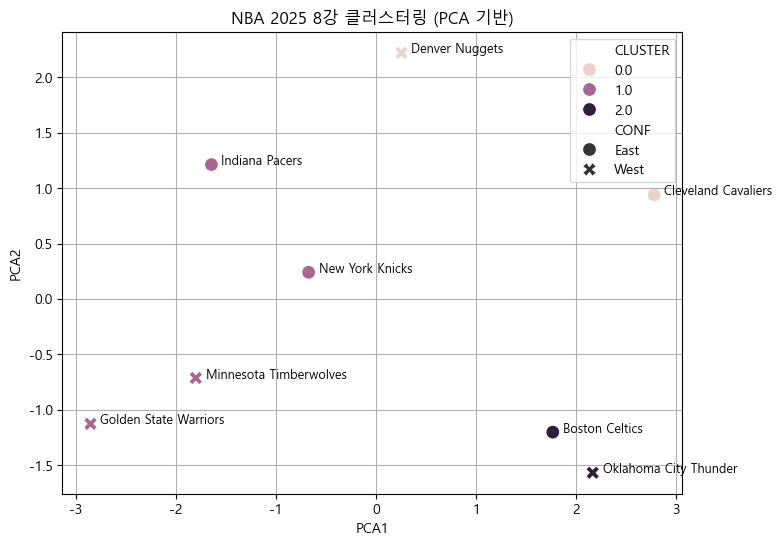

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_final, x='PCA1', y='PCA2', hue='CLUSTER', style='CONF', s=100)
for i, row in df_final.iterrows():
    plt.text(row['PCA1'] + 0.1, row['PCA2'], row['TEAM_NAME'], fontsize=9)
plt.title("NBA 2025 8강 클러스터링 (PCA 기반)")
plt.grid(True)
plt.show()


✅ 클러스터 해석
🔴 Cluster 0 (연한 분홍색)
팀: Denver Nuggets, Clevland Cavliers

공통점:

중간~하위 시드, 페이스 빠르거나 리바운드/수비 중심

조직력 기반이고 일부는 클러치 약세

💡 “수비 집중형 팀 또는 로우 시드 활약 팀 그룹”

🟣 Cluster 1 (자주색)
팀: Indiana Pacers, Minnesota Timberwolves, New York Knicks, Golden State Warriors

공통점:

정규시즌 지표 상위권 (Net Rating, W_PCT, TS%)

PIE와 클러치 승률도 강한 정통 우승 후보형

💡 “전통적 강팀 / 완성도 높은 팀 그룹”

⚫ Cluster 2 (진한 남색)
팀: Boston Celtics, Oklahoma City Thunder

공통점:

공격력 강한 팀 또는 스타파워 기반 팀

높은 PIE 또는 특정 지표 편중 (ex. ORTG 높고, Pace 낮거나 높음)

💡 “공격 특화/특정 핵심 자산 기반 팀”

